# Urban Air Pollution Prediction Challenge 
**Authors**:

- Jedidiah Wambui
- Pauline Onyango
- Dave Karanja
Project Repository: GitHub: https://github.com/karanja-dave/NgaoLabs/tree/main/Tanzania_tourism_prediction

NB: Ensure all dataset files are stored in a data folder in unzipped format. This prevents file path errors and ensures smooth, consistent data loading during analysis.

Date: 08 March 2026

# Project Objective

Predict daily PM2.5 concentrations across multiple cities using satellite-based Sentinel 5P observations and weather data, even in areas lacking ground-based sensors.
## General Objective:
Develop a predictive model to estimate daily PM2.5 concentrations across cities using satellite and weather data, enabling improved air quality monitoring and urban health assessment.

### Specific Objectives:

1. **Data Cleaning and Wrangling:** Process raw satellite and weather datasets by handling missing values, removing outliers, and addressing multicollinearity to create a reliable dataset for modeling.

2. **EDA:** Analyze distributions, correlations, and temporal patterns of pollutants and meteorological features to understand their relationship with PM2.5 levels.

3. **Feature Engineering:** Generate lag features and other derived indicators to capture temporal dependencies and enhance predictive power of the model.

4. **Unsupervised Learning for Structure Discovery:** Apply clustering and dimensionality reduction techniques to uncover patterns in the data that may inform feature selection or model design.

5. **Predictive Modeling and Evaluation:** Build and optimize CatBoost regression models, assess performance using RMSE, interpret feature importance, and produce accurate PM2.5 predictions for unseen test data.




In [ ]:
###Import libraries for 
# 1.EDA 
import pandas as pd 
import numpy as np 
# 2.visulaization 
import matplotlib.pyplot as plt 
import seaborn as sns
# 3. preprocessing 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
# 4. model building 
from sklearn.metrics import mean_squared_error
from catboost import CatBoostRegressor, Pool
# 4. evaluation 
from sklearn.metrics import silhouette_score

# Config pandas-setting pandas to show all rows and columns 
# Show all rows
pd.set_option('display.max_rows', None)
# Show all columns
pd.set_option('display.max_columns', None)
# Optional: widen column display
pd.set_option('display.width', 200)

The configuration on pandas above ensures that pandas does not truncate the display of large DataFrames (By default, it shows only a subset of rows and columns), making it difficult to view the full dataset in the console.

# Data Preparation

In [ ]:
### Data cleaning and wrangling 
def wrangle(path):
    # load data 
    df=pd.read_csv(path)

    # convert date cols to date type 
    df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')

    # drop leakages 
    df=df.drop(columns=['target_min','target_max','target_variance','target_count'],errors='ignore')

    # drop cols with high null count 
    mask_na=df.isna().mean()>0.5
    df.drop(columns=df.columns[mask_na],inplace=True)

    ## imputation
    # select cols with low null count for imputation 
    num_cols_na = df.columns[df.isna().sum() > 0]
    # compute skewness-helps decided cols to be imputed with mean or medain
    skew = df[num_cols_na].skew()
    # separate cols : those to be imputed with mean from those imputed with median
    mean_cols = skew[skew.abs() < 0.5].index
    median_cols = skew[skew.abs() >= 0.5].index
    # compute stats from df
    mean_values = df[mean_cols].mean()
    median_values = df[median_cols].median()
    # imputation with respective stats 
    df[mean_cols] = df[mean_cols].fillna(mean_values)
    df[median_cols] = df[median_cols].fillna(median_values)
    ## dealing with multicollinearity
    #multicollinearity on geometry cols (angle columns)
    sat_cols=df.filter(regex='(O3|CO|HCHO|SO2|CLOUD|AER_AI)_(sensor|solar)_(azimuth|zenith)_angle').columns
    df=df.drop(columns=df[sat_cols])

    # remove outliers only if 'target' exists
    if 'target' in df.columns:
        df = df[df['target'] < 500]



    return df

# load train and tes 
train=wrangle('data/Train.csv')
test=wrangle('data/Test.csv')


Data preparation and cleaning focused on transforming raw data into a structured, consistent format suitable for analysis and modeling. This involved reading the dataset, converting date columns to proper datetime types, removing columns that could leak target information, and eliminating features with excessive missing values. Missing data in remaining columns were imputed using mean or median values based on their distribution skewness. Multicollinearity was addressed by dropping highly correlated satellite geometry variables, and extreme outliers in the target variable were removed to ensure data reliability. The `wrangle` function automates this entire process: it loads the dataset, applies all cleaning steps, handles missing values, reduces multicollinearity, and filters out extreme outliers. The importance of this function lies in standardizing and streamlining preprocessing, ensuring the dataset is clean, consistent, and ready for exploratory analysis and model building, which enhances model performance, reliability, and reduces manual errors.


# EDA

<class 'pandas.DataFrame'>
RangeIndex: 30557 entries, 0 to 30556
Data columns (total 71 columns):
 #   Column                                               Non-Null Count  Dtype         
---  ------                                               --------------  -----         
 0   Place_ID X Date                                      30557 non-null  str           
 1   Date                                                 30557 non-null  datetime64[us]
 2   Place_ID                                             30557 non-null  str           
 3   target                                               30557 non-null  float64       
 4   precipitable_water_entire_atmosphere                 30557 non-null  float64       
 5   relative_humidity_2m_above_ground                    30557 non-null  float64       
 6   specific_humidity_2m_above_ground                    30557 non-null  float64       
 7   temperature_2m_above_ground                          30557 non-null  float64       
 8   u_compo

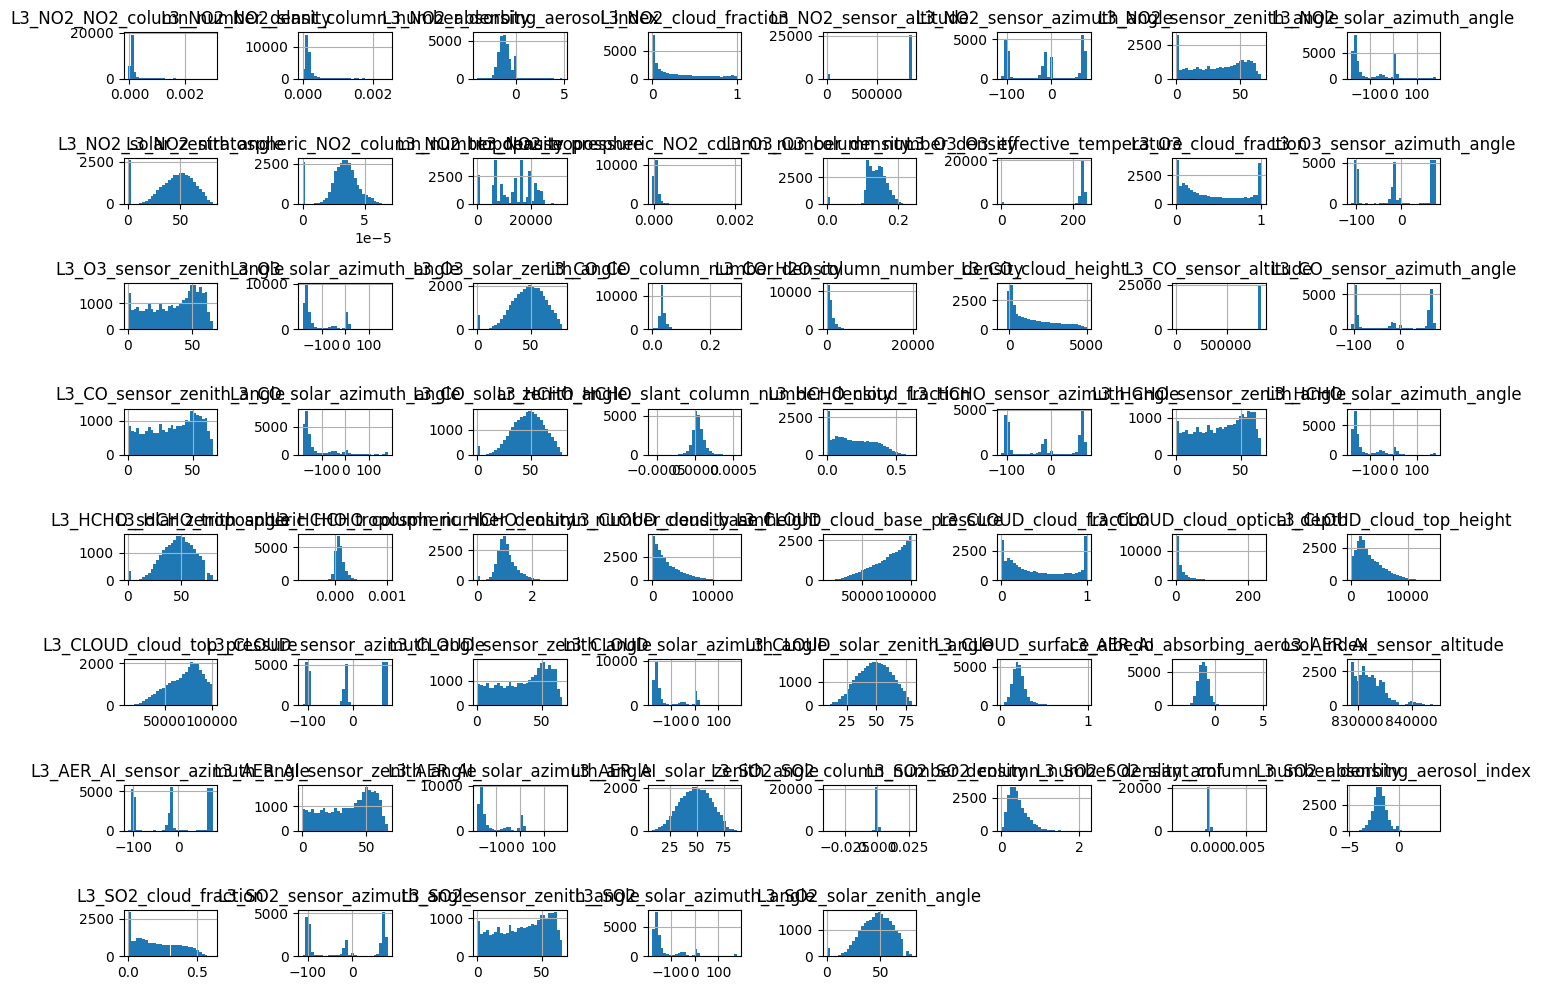

We have so many variables that Visulization is not giving, lets use descriptive stats to analyze numerical cols


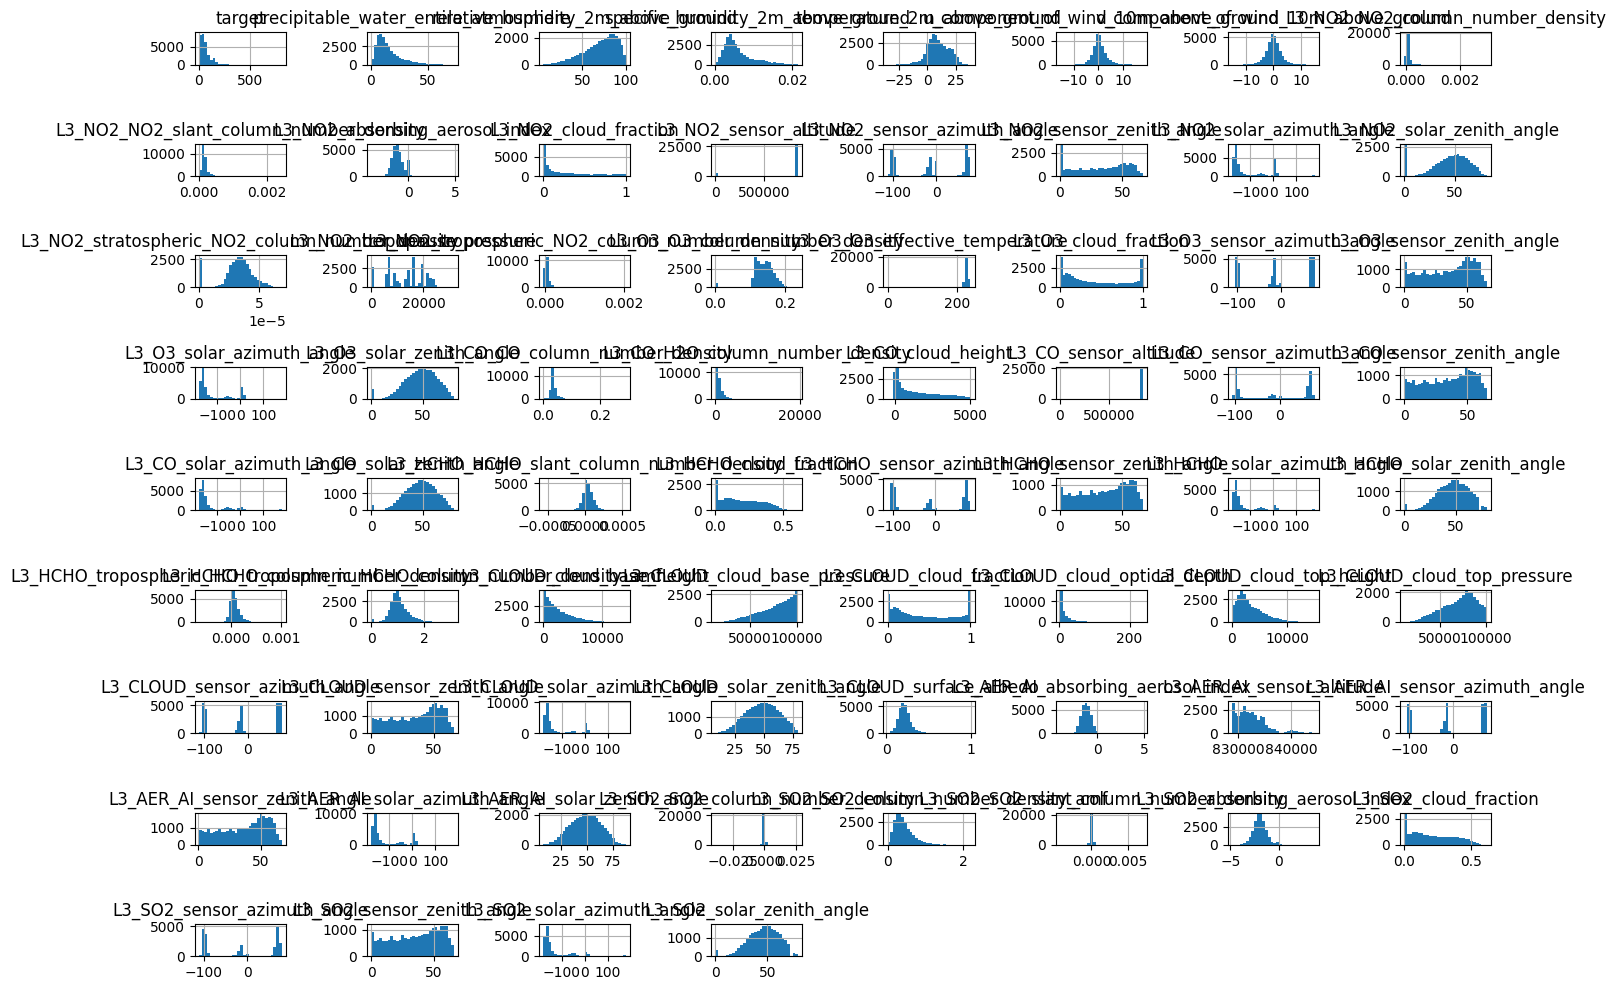

In [5]:
###EDA
#checks top 5 rows 
train.head()
train.info()
test.info()

# check dim - ensures that test and train have same number of variables
train.shape
test.shape

print('\n Train has more variables than test, thus drop variables in train not in test\n')

# check for cols in train and not in test 
set(train.columns) - set(test.columns)
print("\n most of this columns were identified as leakages to the target and were dropped\n Don't drop the the target variable\n")

# check for high null counts 
mask_na=train.isna().mean()
mask_na[mask_na>0.5]
print("\n Now that we've dropped columns with high null counts,\n let's check for cols with low null counts and,\n impute them with median or mean based on their distributions")

# filter out cols with missing values 
num_cols_na = train.columns[train.isna().sum() > 0]
# hist plot to show distribution 
train[num_cols_na].hist(bins=30, figsize=(14,10))
plt.tight_layout()
plt.show()
print("We have so many variables that Visulization is not giving, lets use descriptive stats to analyze numerical cols")

# function for descriptive stats 
def desc_stats(df):
    # select only numerical cols 
    num_df = df.select_dtypes(include=np.number)
    # descriptive stats calc 
    summary = pd.DataFrame({
        "count": num_df.count(),
        "missing": num_df.isna().sum(),
        "missing_pct": num_df.isna().mean(),
        "mean": num_df.mean(),
        "median": num_df.median(),
        "std": num_df.std(),
        "min": num_df.min(),
        "q1": num_df.quantile(0.25),
        "q3": num_df.quantile(0.75),
        "max": num_df.max(),
        "skew": num_df.skew()
    })
    
    return summary.sort_values("missing_pct", ascending=False)

desc_stats(train)

###Visualization
# distribution of numerical cols 
num_cols = train.select_dtypes(include=["float64"]).columns

train[num_cols].hist(bins=30, figsize=(14,10))
plt.tight_layout()
plt.show()

EDA was conducted to understand the structure, quality, and statistical properties of the dataset before modeling. Initial inspection involved viewing the first rows of the training data and examining dataset information to verify variable types and identify potential inconsistencies. The dimensions of the training and test datasets were also compared to ensure that both contained the same set of features, except for the target variable. Any additional variables found in the training data but not present in the test set were investigated and identified as potential target leakages, which were removed to maintain consistency between the datasets.

The analysis further examined missing values across the dataset. Columns with a high proportion of missing values were identified and removed during preprocessing, while those with smaller amounts of missing data were retained for imputation. To understand the distributions of variables requiring imputation, histograms were plotted for numerical columns containing missing values. However, due to the large number of variables, descriptive statistics were also computed to provide a clearer summary of each feature’s characteristics.

A custom descriptive statistics function was used to generate key metrics such as count, missing values, percentage of missing data, mean, median, standard deviation, minimum, quartiles, maximum, and skewness for all numerical variables. This allowed a more comprehensive understanding of feature distributions and helped guide decisions regarding imputation and transformation. Finally, histograms were produced for all numerical variables to visualize their distributions, identify skewness, and detect potential outliers. These insights informed subsequent preprocessing and modeling steps by highlighting patterns, irregularities, and statistical properties within the dataset.

The satellite viewing and solar geometry variables exhibited very high correlations across gases (many above 0.9), indicating strong multicollinearity. Since these variables represent the same measurement geometry repeated for different gas products, only one representative set (NO2 angles) was retained while the others were removed to reduce redundancy and improve model stability.


# Unsupervised Learning - Clustering 
Clustering is an unsupervised machine learning technique used to group data points into clusters based on their similarity. Unlike supervised methods, clustering does not rely on predefined labels; instead, it identifies natural patterns or structures within the data by measuring how closely observations relate to one another across selected features.

The need for clustering arises when there is a requirement to uncover hidden groupings, detect underlying structures, or simplify complex datasets by organizing similar observations together. This process helps reveal relationships that may not be immediately visible, supports deeper understanding of the data distribution, and can assist in tasks such as anomaly detection, segmentation, and feature exploration prior to model development.


In [ ]:
###Unsupervised Learning, Clustering
# get features used in clustering 
features=train.drop(columns=['target','Place_ID X Date','Date','Place_ID'])
X_test = test.drop(columns=['Place_ID X Date','Date','Place_ID'], errors='ignore')

#scaling-clustering depends on distrance 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)
X_test_scaled = scaler.transform(X_test)


The variables features and X_test are created so as to get the predictor variables to be used for clustering. Identifiers such as, `Place_ID X Date`, `Date`, and `Place_ID` and the target are removed as they do not represent measurable characteristics useful for grouping observations based on similarity. The resulting features dataset therefore contains only the numerical attributes that describe each observation and can be used to determine cluster membership. 

Clustering algorithms rely on distance calculations to determine how similar or different observations are. Because different variables may exist on very different numerical scales, features with larger magnitudes could dominate the distance computation and bias the clustering results. To prevent this, `StandardScaler` is applied to transform the variables so that each feature has a mean of zero and a standard deviation of one. The scaler is first fitted on the training features and then used to transform both the training data (`X_scaled`) and the test data (`X_test_scaled`). This ensures that all variables contribute proportionally to the distance calculations, producing more reliable and meaningful cluster formation.

### K-means clustering 
K-Means is an unsupervised machine learning algorithm used to partition data into k distinct clusters based on similarity. It groups observations so that data points within the same cluster are more similar to each other than to those in other clusters, typically measured using Euclidean distance.

The algorithm works by first selecting k initial cluster centroids. Each data point is then assigned to the nearest centroid based on distance. After assignment, the centroids are recalculated as the mean of all points within each cluster. This process of assigning points and recalculating centroids repeats iteratively until the cluster assignments stabilize or changes become minimal. The objective of K-Means is to minimize the within-cluster variance (inertia), ensuring that observations within each cluster are as close as possible to their centroid.


In [1]:
##k-means clustering (elbow method)
inertia_vals=[]
sil_scores=[]

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    labels = kmeans.labels_
    inertia_vals.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Elbow plot
axes[0].plot(range(2,11), inertia_vals, marker='o')
axes[0].set_xlabel("Number of clusters")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")

# Silhouette plot
axes[1].plot(range(2,11), sil_scores, marker='o')
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Analysis")

plt.tight_layout()
plt.show()

print('\n Optimal number pf clusters is where k=7\n This is supported by the elbow method and the silhouette analysis\n')

# optimal k-clustering 
kmeans = KMeans(n_clusters=7, random_state=42)
kmeans.fit_predict(X_scaled)
test['cluster'] = kmeans.predict(X_test_scaled)
train['cluster']=kmeans.labels_
train['cluster'].value_counts().sort_index()

#Principal Component Analysis
pca = PCA(n_components = 2)
df_2d = pca.fit_transform(X_scaled)

# plotting of clusters 
colors = ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd","#8c564b","#17becf"]

for i in range(7):
  mask = train['cluster'] == i
  plt.scatter(df_2d[mask,0], df_2d[mask,1],
              c=colors[i], label =f'cluster {i}')
plt.legend()
plt.title('K-Means Clusters')
plt.show()

NameError: name 'KMeans' is not defined

`K-Means` clustering was implemented to identify natural groupings within the dataset. To determine the optimal number of clusters, the model was fitted iteratively for values of `k` ranging from `2 to 10` using the scaled feature set. For each iteration, two evaluation metrics were computed: `inertia`, which measures the within-cluster sum of squared distances, and the `silhouette score`, which assesses how well observations are separated between clusters. These metrics were stored and visualized using the `Elbow Method` and `Silhouette Analysis` plots.

The Elbow plot illustrates how inertia decreases as the number of clusters increases, while the silhouette plot measures cluster cohesion and separation. Based on the patterns observed in both plots, `k = 7` was selected as the optimal number of clusters, balancing cluster compactness and separation. A K-Means model with seven clusters was then fitted to the scaled training data. The resulting cluster labels were assigned to the training dataset, while the trained model was used to predict cluster membership for the test dataset. The distribution of observations across clusters was also examined to understand cluster sizes.

To visualize the clustering structure, `PCA` was applied to reduce the high-dimensional feature space into two principal components. These components capture the most important variance in the data while enabling two-dimensional visualization. A scatter plot of the PCA-transformed data was then generated, with each observation colored according to its assigned cluster, allowing visual assessment of the cluster separation and structure within the dataset.

The visualization shows that K-Means successfully segmented the dataset into meaningful regions, but the overlap among central clusters indicates that the dataset contains partially mixed feature patterns, which limits perfectly clean separation. The clustering produced identifiable groupings, indicating that the model captured structure in the data. However, the clusters are not perfectly separated, and there is noticeable overlap between several groups. This suggests the model performs moderately well: it detects patterns and partitions the data, but the feature space does not allow completely distinct cluster boundaries.


### Hierachical Clustering 
Hierarchical clustering is an unsupervised learning method used to group observations into clusters based on their similarity. Unlike methods that require a predefined number of clusters, hierarchical clustering builds a hierarchy of clusters that can be visualized as a tree-like structure called a `dendrogram`.

The algorithm works by initially treating each observation as its own cluster. It then repeatedly merges the two most similar clusters based on a chosen distance metric and linkage method (such as Ward’s method). This merging process continues step by step until all observations are combined into a single cluster. The resulting hierarchy allows clusters to be identified by selecting a cut point on the dendrogram, which determines how many clusters are formed based on the distance between merged groups.


In [ ]:
##hierarchical clustering
hc = linkage(X_scaled, method='ward')

# plot the Dendrogram
plt.figure(figsize=(12, 7))
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample Index (or Place_ID)")
plt.ylabel("Distance (Ward)")

dendrogram(hc,
    truncate_mode='lastp',  # show only the last p merged clusters
    p=20,                   # show 20 clusters for readability
    show_leaf_counts=True,leaf_rotation=90.,
    leaf_font_size=12.,show_contracted=True,)

#draw the "Cut Line"
# Adjust this height to see how many clusters it creates
plt.axhline(y=15, color='r', linestyle='--') 
plt.show()

The hierarchical clustering was performed on the scaled dataset using Ward’s linkage, which minimizes variance within clusters. The resulting `dendrogram`,plots sample indices on the `x-axis` and the Ward distance on the `y-axis`. To improve readability, only the last 20 merges are shown, with leaf counts displayed and truncated branches visually contracted. A red dashed line at height 15 indicates the cut-off for defining clusters, providing a clear reference for determining the appropriate number of clusters. This visualization effectively captures the hierarchical structure of the data and supports cluster selection.

The dendogram of the hierarchical clustering reveals three dominant groupings, indicating that the dataset naturally separates into major clusters. Within these primary clusters, there are multiple smaller sub-clusters, reflecting nuanced patterns and heterogeneity among the samples. Some clusters are densely populated, while others are sparse, suggesting uneven distribution and variability in the underlying data. The structure highlights both broad divisions and detailed substructures, implying that the data contains nested relationships that can inform targeted segmentation or analysis.



## Feature Engineering 
Feature engineering is used to enhancing model performance by transforming raw data into meaningful input features. It allows models to capture underlying patterns, temporal dependencies, and relationships that may not be explicit in the original dataset. In time series or sequential data, creating lagged features is a common strategy to provide the model with historical context, enabling it to recognize trends, cycles, and delayed effects. This process can significantly improve predictive accuracy, particularly for models sensitive to temporal dynamics.

In [ ]:
### feature engineering 
def create_lags(df, features, lags, group_col='Place_ID', date_col='Date'):
    # make copy of the df 
    data = df.copy()
    
    # sort by group and date
    data.sort_values([group_col, date_col], inplace=True)
    data.reset_index(drop=True, inplace=True)
    
    # create lag features
    for col in features:
        for lag in lags:
            data[f'{col}_lag{lag}'] = data.groupby(group_col)[col].shift(lag)
    
    return data

lag_features = ['L3_CO_CO_column_number_density','temperature_2m_above_ground','v_component_of_wind_10m_above_ground','u_component_of_wind_10m_above_ground',
'L3_NO2_NO2_slant_column_number_density','L3_HCHO_tropospheric_HCHO_column_number_density','L3_CLOUD_surface_albedo','L3_AER_AI_sensor_altitude']

lags = [1,2,3]

train_lag = create_lags(train, lag_features, lags)
test_lag = create_lags(test, lag_features, lags)

print('\n I decided to create lags because our data is giving TS vibes (Date column)\n Lags were created for columns with high feature importance from the cat model')

Feature engineering is a critical step in enhancing model performance by transforming raw data into meaningful input features. It allows models to capture underlying patterns, temporal dependencies, and relationships that may not be explicit in the original dataset. In time series or sequential data, creating lagged features is a common strategy to provide the model with historical context, enabling it to recognize trends, cycles, and delayed effects. This process can significantly improve predictive accuracy, particularly for models sensitive to temporal dynamics.

The function, `create_lags` generates lagged versions of selected features for each group identified by `Place_ID`. It first sorts the dataset by group and date to maintain temporal order, then shifts the specified columns by the defined lag intervals (1, 2, 3 time steps). The resulting dataset includes new columns representing the previous values of each feature, which the model can use to capture temporal dependencies. This approach was applied to high-importance features identified from the CatBoost model to leverage their predictive value in a time-aware manner.


# Model Building 


In [ ]:
##data splitting : train and validation sets 

# separte targed and feature cols 
X_train=train.drop(columns=['target','Place_ID X Date','Date','Place_ID'])
y_train=train['target']
# target and feature separation for lagged data 
X_train_lag=train_lag.drop(columns=['target','Place_ID X Date','Date','Place_ID'])
y_train_lag=train_lag['target']
# split train and validation sets
 
cutoff = int(len(X_train)*0.8)
# split for original data 
X_Train, y_Train = X_train.iloc[:cutoff],y_train.iloc[:cutoff]
X_val, y_val = X_train.iloc[cutoff:],y_train.iloc[cutoff:]

# split for lagged data 
cutoff_lag = int(len(X_train_lag) * 0.8)
X_Train_lag, y_Train_lag = X_train_lag.iloc[:cutoff_lag], y_train_lag.iloc[:cutoff_lag]
X_val_lag, y_val_lag     = X_train_lag.iloc[cutoff_lag:], y_train_lag.iloc[cutoff_lag:]

The data splitting process begins by separating the `features` from the `target` variable to ensure the model only learns from input patterns without access to the outcomes it is meant to predict. This creates the foundation for proper supervised learning. A `validation set` is then designated to evaluate model performance on unseen data, providing a check against overfitting and guiding hyperparameter tuning.

Because the dataset has a temporal structure indicated by the `Date` column, random splitting would mix past and future observations, introducing data leakage. The code instead uses `cut-off points` to split the data chronologically, training the model on historical data and validating it on later time periods. This approach preserves temporal dependencies, aligns with the lag feature creation in the `create_lags` function, and ensures that the model is evaluated in a scenario that reflects actual predictive use cases.


# init model : 
cb_model = CatBoostRegressor(iterations=30000,
                             learning_rate=0.045,
                             depth=8,
                             eval_metric='RMSE',
                             random_seed = 42,
                             bagging_temperature = 0.2,
                             od_type='Iter',
                             metric_period = 50,
                             od_wait=300)
cb_model.fit(X_Train, y_Train,
             use_best_model=True,
             verbose=50)

y_pred = cb_model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print("Validation RMSE:", rmse)


# Feature importance 
# Create a Pool object for correct handling
train_pool = Pool(X_Train, label=y_Train)

importances = cb_model.get_feature_importance(train_pool)
feature_names = X_Train.columns

# Print feature importances
for name, imp in zip(feature_names, importances):
    print(f"{name}: {imp:.4f}")

# plot feta importance 
plt.figure(figsize=(12,8))
plt.barh(feature_names, importances)
plt.xlabel("Feature Importance")
plt.title("CatBoost Feature Importance")
plt.gca().invert_yaxis()  # highest importance on top
plt.show()

pd.DataFrame({
    "feature":X_Train.columns,
    'importance':importances
})

The process involves training a gradient boosting model to predict the target variable using the available features. The model is configured to balance learning speed, complexity, and overfitting through specific settings: the number of iterations determines how many steps it takes to fit the data, the learning rate controls the aggressiveness of updates, and tree depth limits the complexity of each decision tree to balance detail capture with generalization. Early stopping monitors performance and halts training if no improvement is observed, preventing overfitting, while bagging temperature introduces randomness to improve robustness. The model is trained on historical data, retaining the best-performing version, and its accuracy is evaluated on a separate validation set. To interpret the results, feature importance is assessed, highlighting which variables most strongly influence predictions and providing insight into the factors driving the outcomes.

**NB: Because of the high number of iterations, the model is computationally heavy and takes some time to fit**


In [ ]:
# imporved model : with lags of significant features 
cb_model_lagged = CatBoostRegressor(iterations=30000,
                             learning_rate=0.045,
                             depth=8,
                             eval_metric='RMSE',
                             random_seed = 42,
                             bagging_temperature = 0.2,
                             od_type='Iter',
                             metric_period = 50,
                             od_wait=300)


cb_model_lagged.fit(X_Train_lag, y_Train_lag,
    eval_set=(X_val_lag, y_val_lag),
    use_best_model=True,
    verbose=50
)

y_pred_lag = cb_model_lagged.predict(X_val_lag)
rmse_lag = np.sqrt(mean_squared_error(y_val_lag, y_pred_lag))
print("Validation RMSE:", rmse_lag)
# predicting the target on test 
X_test=test_lag[X_train_lag.columns]
y_pred_test=cb_model_lagged.predict(X_test)

The improved CatBoost regression model was fitted using the lagged features created from previously identified important variables. By including these lagged features, the model captures temporal patterns and dependencies that were not present in the original data. The model is configured with the same parameters as before and is trained on the lagged training set while validating on the corresponding lagged validation set. After training, predictions for the validation set were evaluated using RMSE, which decreased from approximately 31 with the original model to around 28 with the lagged-feature model. This demonstrates that including past values of key features significantly enhanced performance. The model was then applied to the test set to generate predictions using the same lagged feature structure.

In [ ]:
# create submission df
submission = pd.DataFrame({
    'Place_ID X Date': test["Place_ID X Date"],
    "total_cost": y_pred_test
})

# Export to CSV
submission.to_csv('first_submission.csv', index=False)

A submission file was created containing the `Place_ID X Date` identifiers and the predicted `total_cost` values. The file has been exported to CSV in the format required by Zindi for submission.
